#  Intro

This notebook is to test population decoders, i.e. to decode one variable from one session.

Another notebook exists to run the same method for all sessions and multiple variabless.

---
# Setup

In [1]:
#%% Imports
import pandas as pd

from popy.decoding.population_decoders import run_decoder

from popy.io_tools import load_behavior, load_neural_data
from popy.behavior_data_tools import *
from popy.neural_data_tools import *
from popy.decoding.population_decoders import linear_decoding
from popy.plotting.plotting_tools import plot_keypoints


In [2]:
##% Plotting functions
def plot_decoding_results(res, n_extra_trials=(0, 0), title=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    if title is not None:
        ax.set_title(title)

    colors = {'LPFC': 'tab:blue', 'MCC': 'grey'}
    linestyles = {'scores': '-', 'perm_mean +- 2std': '--'}

    for area in res.area.values:
        res_temp = res.sel(area=area)
        ax.plot(res_temp.time, res_temp.scores, label=area, alpha=.8, color=colors[area]) 
        
        # bold when significant (2 std)
        '''for i in range(res.scores.shape[0]-1):
            if res.scores[i] > res.perm_mean[i] + 2*res.perm_std[i]:
                ax.plot([res.time[i], res.time[i+1]], [res.scores[i], res.scores[i+1]], color='tab:red', alpha=.5, linewidth=4)'''
        #ax.plot(res.time[res.scores > res.perm_mean + 2*res.perm_std], res.scores[res.scores > res.perm_mean + 2*res.perm_std], color='tab:blue', alpha=.8, linewidth=5)

        ax.plot(res_temp.time, res_temp.perm_mean, alpha=.8, linestyle='--', color=colors[area])
        ax.fill_between(res_temp.time, res_temp.perm_mean - res_temp.perm_std, res_temp.perm_mean + res_temp.perm_std, alpha=.2,  color=colors[area])
            
    plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8, rotation=70)
    ax.grid(axis='x', alpha=.5)
    # add linestyles to legend in black
    for key, value in linestyles.items():
        ax.plot([], [], linestyle=value, color='k', label=key)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # limits of the plot by default

def plot_multiple_decoding_results(reses, n_extra_trials=(0, 0), title=None, ax=None):
    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    areas =['LPFC', 'MCC']
    for label, res in reses.items():
        for i, ax in enumerate(axs):
            res_temp = res.sel(area=areas[i])
            axs[i].plot(res_temp.time, res_temp.scores, label=label, alpha=.8)   
    for i, ax in enumerate(axs):
        ax.set_title(areas[i])
        plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8, rotation=70)
        ax.grid(axis='x', alpha=.5)
        ax.legend()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    if title is not None:
        fig.suptitle(title)
    fig.tight_layout()

---
# Main

In [3]:
monkey, session = 'po', '291020'  # 040321

PARAMS = {
    'conditions': ['stay_value'], #[f'shift_value_{alpha:.2f}' for alpha in np.linspace(.05, .95, 19)],  # Conditions to decode
    'group_targets': None, #['target', 'target_shuffled'],
    'K_fold': 10,
    'step_len': .2,
    'n_perm': 100, 
    'n_extra_trials': (0, 0),
}

res_xr_target, _ = run_decoder(monkey, session, PARAMS, n_jobs=-1, load_data=True, save_data=False) #‹#####_decoder(monkey, session, PARAMS, n_jobs=-1)

res_xr_target

Running for monkey po and session 291020
Monkey: po, Session: 291020 - Removed 27 / 48 neurons
Decoding stay_value in LPFC
Decoding time point 1/38
Decoding time point 2/38
Decoding time point 3/38
Decoding time point 4/38
Decoding time point 5/38
Decoding time point 6/38
Decoding time point 7/38
Decoding time point 8/38
Decoding time point 9/38
Decoding time point 10/38
Decoding time point 11/38
Decoding time point 12/38
Decoding time point 13/38
Decoding time point 14/38
Decoding time point 15/38
Decoding time point 16/38
Decoding time point 17/38
Decoding time point 18/38
Decoding time point 19/38
Decoding time point 20/38
Decoding time point 21/38
Decoding time point 22/38
Decoding time point 23/38
Decoding time point 24/38
Decoding time point 25/38
Decoding time point 26/38
Decoding time point 27/38
Decoding time point 28/38
Decoding time point 29/38
Decoding time point 30/38
Decoding time point 31/38
Decoding time point 32/38
Decoding time point 33/38
Decoding time point 34/38
De

KeyboardInterrupt: 

In [ ]:
"""mean_xr = res_xr_target.sel(target=['stay_value']).mean(dim='target')
#res_xr_targetcopy = res_xr_target.sel(target='stay_value_1.0') = mean_xr
# add new dim: 'target
mean_xr = mean_xr.expand_dims('target')
mean_xr = mean_xr.assign_coords(target=['mean'])

res_xr_target = res_xr_target.copy()
# remove the three targets, add the mean    
'''
res_xr_target = res_xr_target.where(res_xr_target.target != 'stay_value_1.0', drop=True)
res_xr_target = res_xr_target.where(res_xr_target.target != 'stay_value_2.0', drop=True)
res_xr_target = res_xr_target.where(res_xr_target.target != 'stay_value_3.0', drop=True)'''
res_xr_target = res_xr_target.combine_first(mean_xr)
"""

"mean_xr = res_xr_target.sel(target=['stay_value']).mean(dim='target')\n#res_xr_targetcopy = res_xr_target.sel(target='stay_value_1.0') = mean_xr\n# add new dim: 'target\nmean_xr = mean_xr.expand_dims('target')\nmean_xr = mean_xr.assign_coords(target=['mean'])\n\nres_xr_target = res_xr_target.copy()\n# remove the three targets, add the mean    \n'''\nres_xr_target = res_xr_target.where(res_xr_target.target != 'stay_value_1.0', drop=True)\nres_xr_target = res_xr_target.where(res_xr_target.target != 'stay_value_2.0', drop=True)\nres_xr_target = res_xr_target.where(res_xr_target.target != 'stay_value_3.0', drop=True)'''\nres_xr_target = res_xr_target.combine_first(mean_xr)\n"

In [ ]:
res_xr_target.scores

<xarray.DataArray 'scores' (session: 1, target: 1, group_target: 1, time: 75,
                            area: 2)>
array([[[[[-0.05191366, -0.02662315],
          [-0.12571558, -0.01838287],
          [-0.07171573, -0.04916946],
          [-0.09461628, -0.09230428],
          [-0.07114695, -0.06652398],
          [-0.11037154, -0.08944069],
          [-0.06806755,  0.00945817],
          [-0.04205944, -0.0227445 ],
          [-0.16583919, -0.09752513],
          [-0.14764956, -0.03655557],
          [-0.11796613, -0.03929575],
          [-0.052479  ,  0.03736268],
          [-0.04442193, -0.07989012],
          [-0.17893595, -0.03697981],
          [-0.05338378, -0.03530594],
          [-0.06168651, -0.09215873],
          [-0.0600113 ,  0.04170423],
          [-0.00182119,  0.02130759],
          [-0.06305076, -0.02414823],
          [-0.00405848,  0.08872378],
...
          [-0.11548393,  0.0428496 ],
          [-0.01440981,  0.00053555],
          [ 0.09031898,  0.0575888 ],
          [ 0.08322633,  0.05468569],
          [ 0.01107439, -0.01903765],
          [-0.04377253, -0.05256831],
          [-0.10205412, -0.04065781],
          [-0.09085454, -0.00963165],
          [-0.10316761, -0.08841654],
          [-0.10773089, -0.12508385],
          [-0.10337208, -0.06514526],
          [-0.02907587, -0.06962672],
          [-0.03682753, -0.05008099],
          [-0.08076059, -0.08251319],
          [-0.1075428 , -0.05096046],
          [-0.12461202,  0.00912958],
          [-0.07704947, -0.05065354],
          [-0.13366879, -0.0338362 ],
          [-0.01003034, -0.04300516],
          [-0.04466678, -0.03885122]]]]])
Coordinates:
  * target        (target) <U50 'stay_value'
  * area          (area) <U10 'LPFC' 'MCC'
  * time          (time) float64 -7.5 -7.3 -7.1 -6.9 -6.7 ... 6.7 6.9 7.1 7.3
  * group_target  (group_target) <U50 'None'
  * session       (session) <U9 'po_210622'
    monkey        (session) <U2 'po'

stay_value
stay_value


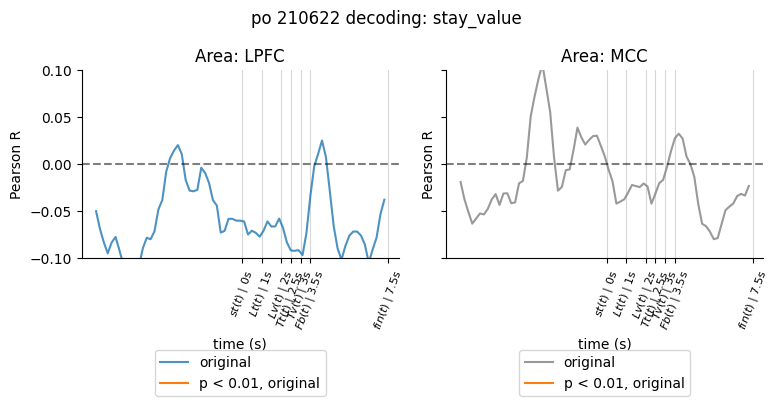

In [ ]:
# plot results
areas = res_xr_target.area.values

linestyles = {'target_shuffled': '-', 'target': '--', None: '-'}
labels = {'target_shuffled': 'simple 3fold CV', 'target': 'target based 3fold CV', None: 'original'}

fig, axs = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)
fig.suptitle(f'{monkey} {session} decoding: {PARAMS["conditions"][0]}')

for a, area in enumerate(areas):
    ax = axs[a]
    #if not label == 'original': continue
    for t, target in enumerate(res_xr_target.target.values):
        print(target)
        if target in ['stay_value_1.0', 'stay_value_2.0', 'stay_value_3.0']:
            continue
        for l, label in enumerate(PARAMS['group_targets']):
            data_temp = res_xr_target.sel(session=f'{monkey}_{session}', target=target, area=area, group_target=str(label))

            ax.plot(data_temp.time, np.convolve(data_temp.scores, np.ones(5)/5, mode='same'),  #data_temp.scores,
                    label=labels[label], color='tab:blue' if area == 'LPFC' else 'grey',
                    alpha=.8, linestyle=linestyles[label])
            #ax.fill_between(data_temp.time, data_temp.scores - data_temp.cv_std, data_temp.scores + data_temp.cv_std, alpha=.2, color='tab:blue')

            #ax.plot(data_temp.time, data_temp.perm_mean, color='black', linestyle='--')
            #ax.fill_between(data_temp.time, data_temp.perm_mean - 2*data_temp.perm_std, data_temp.perm_mean + 2*data_temp.perm_std, alpha=.2, color='black')

    #ax.plot(data_temp.time, data_temp.cv_std, color='tab:orange', alpha=.5, label='std of CVs')

    plim = 0.01
    if not PARAMS['n_perm'] is None:
        if PARAMS['n_perm'] >= 100 :
            for t, label in enumerate(PARAMS['group_targets']):
                data_temp = res_xr_target.sel(session=f'{monkey}_{session}', target=target, area=area, group_target=str(label))
                add_label = True
                for i in range(data_temp.time.shape[0]-1):
                    if data_temp.pvals[i] < plim:
                        ax.plot([data_temp.time[i], data_temp.time[i+1]], [.6+t/50, .6+t/50], color='tab:red' if label=='target' else 'tab:orange', 
                                label=f'p < {plim}, {labels[label]}' if add_label else None)
                        add_label = False 

            #ax.set_ylim([-.2, 1])

    plot_keypoints(ax, n_extra_trials=PARAMS['n_extra_trials'], fontsize=8, rotation=70)
    ax.grid(axis='x', alpha=.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.45),  # Centered below the plot
    )
    ax.set_title(f"Area: {area}")
    ax.set_ylabel('Pearson R')
    ax.axhline(0, color='black', linestyle='--', alpha=.5)
    #ax.set_xlim([0, 5])
    ax.set_ylim([-0.1, .1])

plt.tight_layout()
    